In [1]:
from spin_lattices import KagomeLattice, SpinLattice, ChainLattice, FactorLattice
from sympy.combinatorics import Permutation, PermutationGroup
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from igraph import Graph
import igraph
import itertools
from heisenberg_hamiltonians import HeisenbergJ1J2
from utils import one
from sympy.combinatorics import Permutation, PermutationGroup
from pathlib import Path

2023-06-29 14:56:05.756 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-06-29 14:56:05.759 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-06-29 14:56:05.810 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [2]:
def is_inside_starry_region(site, center, starry_region):
    # get polar coordinates of site - center:
    r, phi = np.linalg.norm(site - center), np.arctan2(site[1] - center[1], site[0] - center[0])
    return r <= starry_region(phi)

def is_inside_starry_region_row(row, center, starry_region):
    return is_inside_starry_region(row[['emb_x', 'emb_y']].to_numpy(), center, starry_region)

def circle_starry_region(radius):
    return lambda phi: radius

def hexagon_with_ear_starry_region(radius):
    def wrapper(phi):
        phi = phi % (np.pi / 3) - np.pi / 6
        return radius * (1 + 0.3 * (phi > 0))  / np.cos(np.abs(phi))
    return wrapper

def hexagon_with_notch_starry_region(radius):
    def wrapper(phi):
        phi_ = phi % (np.pi / 3) - np.pi / 6
        return radius * (1 - 0.3 * (np.abs((phi + np.pi / 12) % (2 * np.pi / 3)) < 0.5))  / np.cos(np.abs(phi_))
    return wrapper


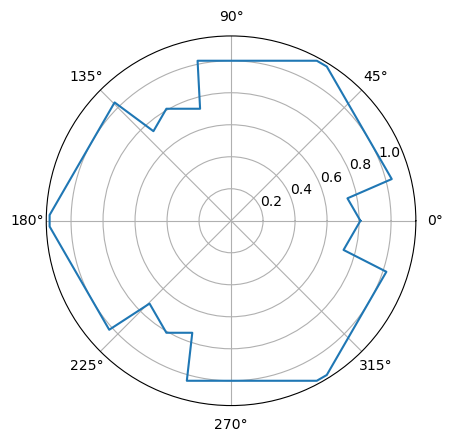

In [7]:
phi = np.linspace(0, 2 * np.pi, 100)
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(phi, hexagon_with_notch_starry_region(1)(phi))

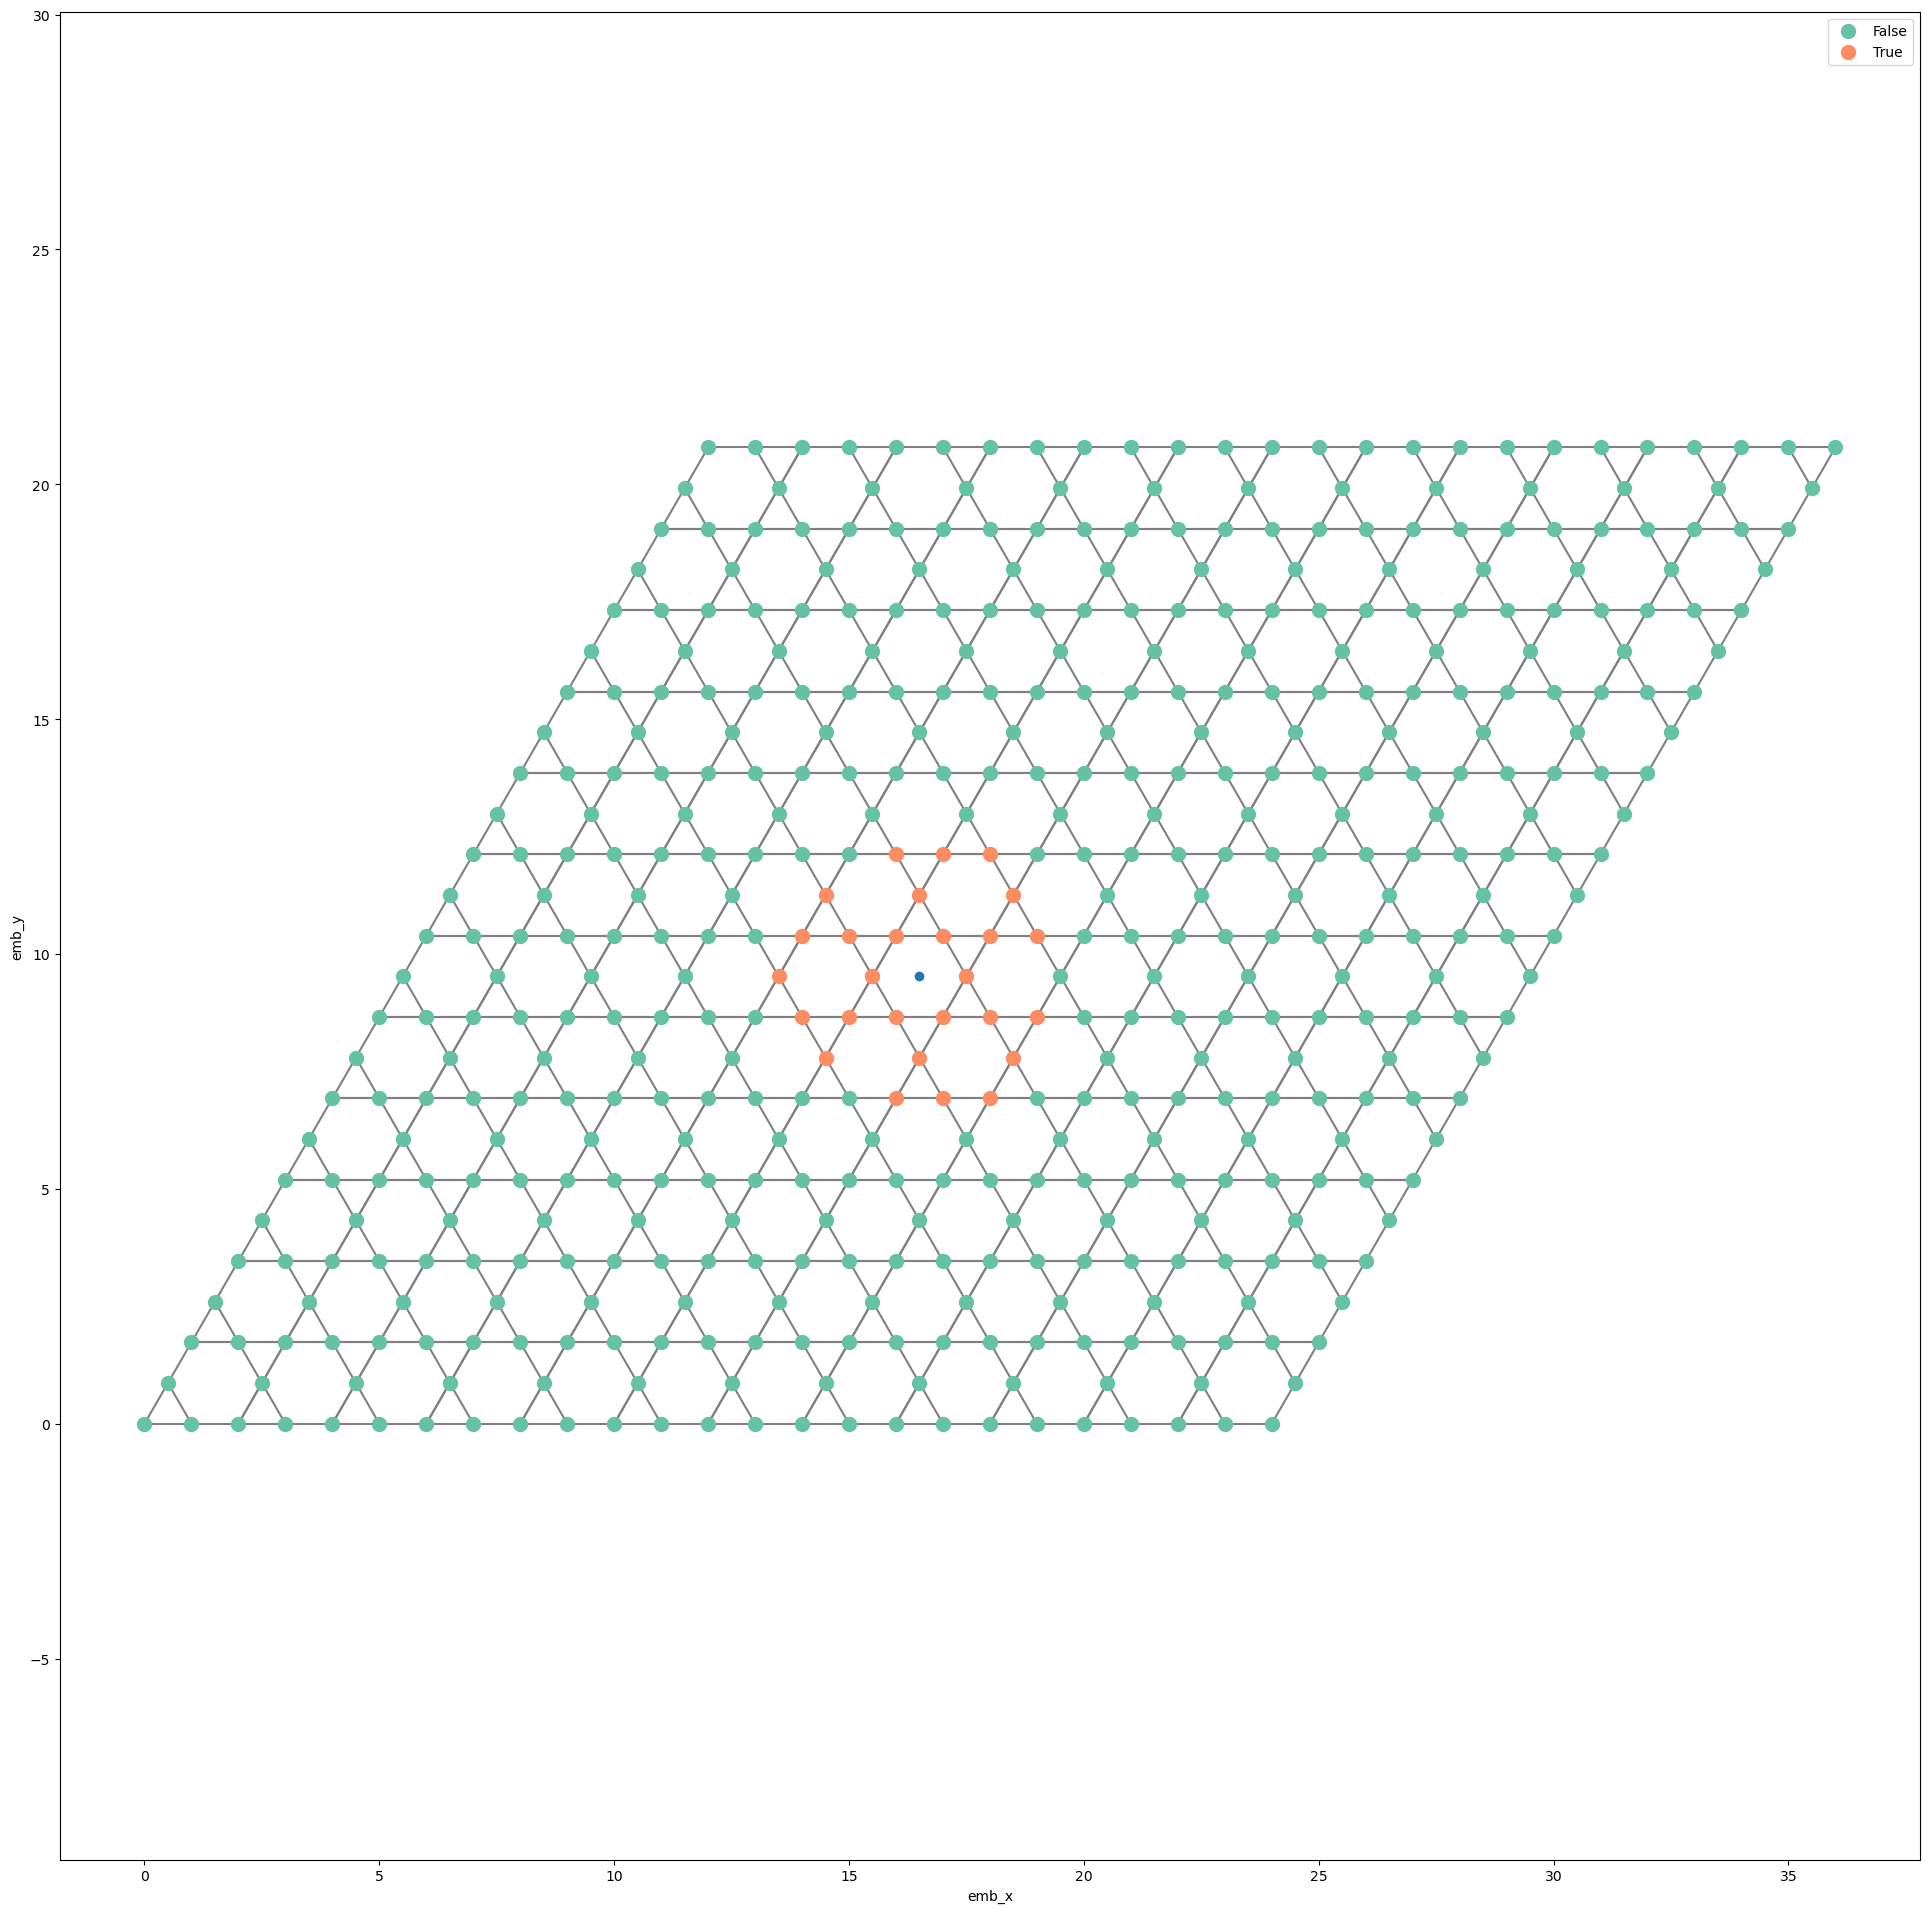

In [9]:
lat = KagomeLattice(12, 12, isotropic=True)
u, v = lat.lattice_basis.T
hexagonal_center = lat.sites_df[['emb_x', 'emb_y']].mean().to_numpy() - u - v

fundamental_domain = lat.sites_df.query('is_canonical').apply(
    is_inside_starry_region_row,
    axis=1,
#    args=(hexagonal_center, hexagon_with_notch_starry_region(np.linalg.norm(u + v) * 1.7)),
    args=(hexagonal_center, hexagon_with_notch_starry_region(np.linalg.norm(u + v) * 1.7)),
).to_numpy()

plt.figure(figsize=(24, 24))
lat.plot(spins=fundamental_domain, ax=plt.gca(), show_numbers=False)

plt.plot(*hexagonal_center, 'o')

In [10]:
tx = Permutation(lat.get_translation("x"))
ty = Permutation(lat.get_translation("y"))

# righttop = tx**2 * ty**2
# rightbottom = tx**4 * ty ** (-2)
# bottom = tx ** (2) * ty ** (-4)

right = tx ** 3
topright = ty ** 3
bottomright = tx ** 3 * ty ** (-3)

fundamental_domain_elements = list(np.argwhere(fundamental_domain).flatten())
group_elements = list(
    itertools.chain(*[[right**i, topright**i, bottomright**i] for i in [1, -1]])
    # itertools.chain(*[[righttop ** i, rightbottom ** i, bottom ** i] for i in [1, -1]])
)

In [11]:
factor_lattice = FactorLattice(
    initial_lattice=lat,
    group_elements=group_elements,
    fundamental_domain=fundamental_domain_elements,
)

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

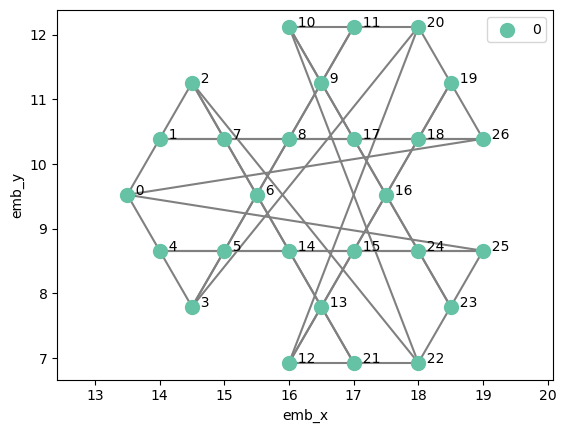

In [12]:
fig, ax = plt.subplots()
factor_lattice.plot(ax=ax)

In [13]:
automorphisms = set(Permutation(g) for g in factor_lattice.get_automorphisms())

In [14]:
def apply(g: Permutation, elements: list[int]):
    return [g(x) for x in elements]

In [15]:
def filter_permutations(group_elements, preimage, image):
    return [g for g in group_elements if apply(g, preimage) == image]


generators = dict(
    tx=one(filter_permutations(automorphisms, [5, 14, 6, 4], [15, 24, 16, 14])),
    ty=one(filter_permutations(automorphisms, [3, 5, 14, 6], [6, 8, 17, 9])),
    rotation=one(filter_permutations(automorphisms, [6, 14, 15], [14, 15, 16])),
    flip=one(filter_permutations(automorphisms, [0, 6, 4], [0, 6, 1])),
#    nonplanar4=one(filter_permutations(automorphisms, [0, 21, 16, 11], [11, 16, 21, 0]))
)

# generators = dict(
#     tx=one(filter_permutations(automorphisms, [8, 9, 19, 10], [19, 20, 31, 21])),
#     ty=one(filter_permutations(automorphisms, [9, 19, 10, 7], [12, 22, 13, 10])),
#     rotation=one(filter_permutations(automorphisms, [10, 19, 20], [19, 20, 21])),
#     flip=one(filter_permutations(automorphisms, [0, 10, 21, 9], [0, 10, 21, 11])),
# )
generated_group = PermutationGroup(list(generators.values()))
rest_elements = automorphisms - generated_group.elements

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

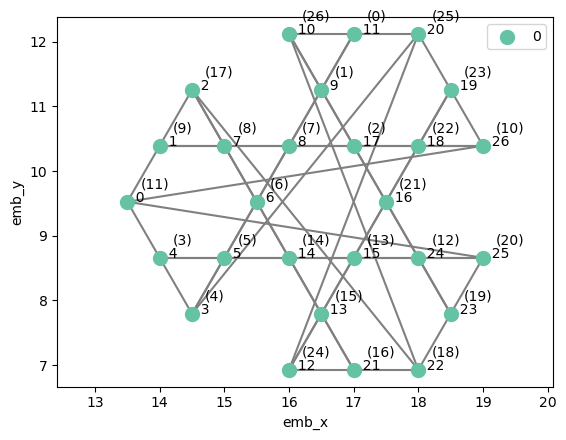

In [16]:
factor_lattice.plot(permutation=one(filter_permutations(automorphisms, [0, 21, 16, 11], [11, 16, 21, 0])))

In [14]:
system = HeisenbergJ1J2(
    lattice=factor_lattice,
    J1=1.0,
    use_symmetries=True,
    spin_inversion=None,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True
)

2023-06-29 14:35:05.561 | WARNING  | heisenberg_hamiltonians:__init__:424 - Symmetries are not tested with KagomeLattice12x12_isotropic_factor_149-150-151-152-154-155-181-182-183-184-185-186-187-188-189-190-216-217-218-219-220-221-222-223-224-225-226-251-252-253-254-255-256-257-258-291, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-06-29 14:35:05.563 | DEBUG    | heisenberg_hamiltonians:__init__:456 - number_spins=36
2023-06-29 14:35:05.623 | DEBUG    | heisenberg_hamiltonians:__init__:466 - Symmetry group contains 144 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-06-29 14:36:17.281 | DEBUG    | heisenberg_hamiltonians:__init__:475 - Hilbert space dimension is 63044766


In [15]:
system.get_eigenstates(1)

2023-06-29 14:36:35.446 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:98 - Calculating eigenvalues / eigenstates
